## Princípios de Eletromag no Sionna

referênica: [Link Tutorial Oficial](https://nvlabs.github.io/sionna/rt/em_primer.html#coordinate-system-rotations-and-vector-fields)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Direciona o interpretador para pasta onde estao os arquivos
%cd "/content/drive/MyDrive/Estudos/UFRN/POSGRADUACAO/2025.2/RADIOPROPAGACAO/Aprendendo Sionna"
!pwd


/content/drive/MyDrive/Estudos/UFRN/POSGRADUACAO/2025.2/RADIOPROPAGACAO/Aprendendo Sionna
/content/drive/MyDrive/Estudos/UFRN/POSGRADUACAO/2025.2/RADIOPROPAGACAO/Aprendendo Sionna


In [1]:
# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

no_preview = False # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, PlanarArray

In [20]:
# Load integrated scene
# scene = load_scene(sionna.rt.scene.munich) # Try also sionna.rt.scene.etoile
# scene = load_scene("will_testes.xml")
scene = load_scene("LAB_MODEL.xml")
# scene = load_scene(sionna.rt.scene.simple_street_canyon, merge_shapes=False)

In [6]:
list(scene.radio_materials.keys())

['itu_concrete', 'itu_wood', 'itu_glass']

In [21]:
if not no_preview:
    scene.preview();

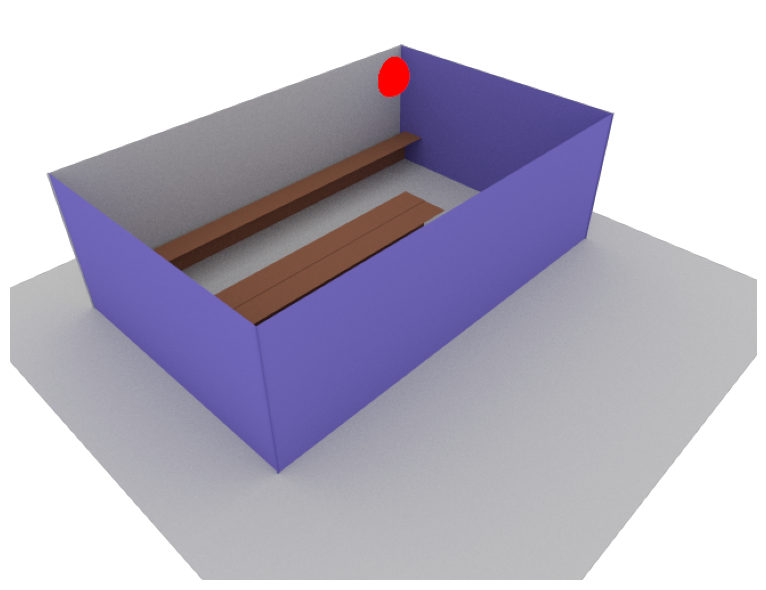

In [26]:
# Only availabe if a preview is open
if not no_preview:
    scene.render(camera="preview", num_samples=512);

In [55]:
# Only availabe if a preview is open
if not no_preview:
    scene.render_to_file(camera="preview",
                         filename="scene.png",
                         resolution=[650,500]);

In [54]:

cam = Camera(position=[-360,145,200], look_at=[-115,33,1.5])
if no_preview:
    scene.render(camera=cam, resolution=[650, 500], num_samples=512);
else:
    scene.preview();

In [27]:
print(type(scene.objects))
scene.objects

<class 'dict'>


{'no-name-9': <sionna.rt.scene_object.SceneObject at 0x272c0bbe270>,
 'no-name-10': <sionna.rt.scene_object.SceneObject at 0x272c0bbda00>,
 'no-name-11': <sionna.rt.scene_object.SceneObject at 0x272c0e2fb60>}

In [28]:
for chave, valor in scene.objects.items():
    print(f"{chave}: {valor}")
    floor = scene.get(chave)
    print("Position (x,y,z) [m]: ", floor.position)
    print("Orientation (alpha, beta, gamma) [rad]: ", floor.orientation)
    print("Scaling: ", floor.scaling)

no-name-9: <sionna.rt.scene_object.SceneObject object at 0x00000272C0BBE270>
Position (x,y,z) [m]:  [[4.37825, 2.94517, 0.4]]
Orientation (alpha, beta, gamma) [rad]:  [[0, 0, 0]]
Scaling:  [[1, 1, 1]]
no-name-10: <sionna.rt.scene_object.SceneObject object at 0x00000272C0BBDA00>
Position (x,y,z) [m]:  [[4.44004, 2.8896, 1.5]]
Orientation (alpha, beta, gamma) [rad]:  [[0, 0, 0]]
Scaling:  [[1, 1, 1]]
no-name-11: <sionna.rt.scene_object.SceneObject object at 0x00000272C0E2FB60>
Position (x,y,z) [m]:  [[4.79562, 4.12077, 1.5]]
Orientation (alpha, beta, gamma) [rad]:  [[0, 0, 0]]
Scaling:  [[1, 1, 1]]


In [102]:
def config_scene():
    """Load and configure a scene"""
    scene = load_scene("LAB_MODEL.xml")
    # scene = load_scene()
    scene.bandwidth=3.2e6

    # Configure antenna arrays for all transmitters and receivers
    scene.tx_array = PlanarArray(num_rows=1,
                                 num_cols=1,
                                 pattern="tr38901",
                                 polarization="V")

    scene.rx_array = PlanarArray(num_rows=1,
                                 num_cols=1,
                                 pattern="iso",
                                 polarization="V")

    # Place transmitters
    positions = np.array(
                 [[1.036, 0.677, 1.870],
                  
                 ])
    look_ats = np.array(
                [[0,0,0],
                 
                ])
    power_dbms = [10]

    for i, position in enumerate(positions):
        scene.add(Transmitter(name=f'tx{i}',
                              position=position,
                              look_at=look_ats[i],
                              power_dbm=power_dbms[i]))

    return scene


# Render an image
cam = Camera(position=[0,0,20],
                    orientation=np.array([0,np.pi/2,-np.pi/2]))
# Load and configure scene
scene_etoile = config_scene()
# scene_etoile.preview()
# Compute the SINR map
rm_etoile = rm_solver(scene_etoile,
                      max_depth=5,
                      samples_per_tx=10**7,
                      cell_size=(0.1, 0.1),
                      center=[4, 3, 0.4],
                      size=[20, 20],
                      orientation=[0, 0, 0])

scene_etoile.preview(radio_map=rm_etoile,
                         rm_metric="sinr",
                         rm_vmin=-20,
                         rm_vmax=50)

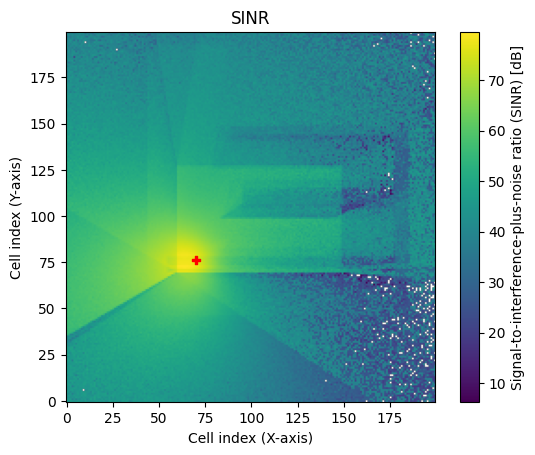

In [103]:
rm_etoile.show(metric="sinr");

In [48]:
def config_scene(num_rows, num_cols):
    """Load and configure a scene"""
    scene = load_scene(sionna.rt.scene.etoile)
    scene.bandwidth=100e6

    # Configure antenna arrays for all transmitters and receivers
    scene.tx_array = PlanarArray(num_rows=num_rows,
                                 num_cols=num_cols,
                                 pattern="tr38901",
                                 polarization="V")

    scene.rx_array = PlanarArray(num_rows=1,
                                 num_cols=1,
                                 pattern="iso",
                                 polarization="V")

    # Place transmitters
    positions = np.array(
                 [[-150.3, 21.63, 42.5],
                  [-125.1, 9.58, 42.5],
                  [-104.5, 54.94, 42.5],
                  [-128.6, 66.73, 42.5],
                  [172.1, 103.7, 24],
                  [232.8, -95.5, 17],
                  [80.1, 193.8, 21]
                 ])
    look_ats = np.array(
                [[-216, -21,0],
                 [-90, -80, 0],
                 [-16.5, 75.8, 0],
                 [-164, 153.7, 0],
                 [247, 92, 0],
                 [211, -180, 0],
                 [126.3, 194.7, 0]
                ])
    power_dbms = [23, 23, 23, 23, 23, 23, 23]

    for i, position in enumerate(positions):
        scene.add(Transmitter(name=f'tx{i}',
                              position=position,
                              look_at=look_ats[i],
                              power_dbm=power_dbms[i]))

    return scene


# Load and configure scene
num_rows=8
num_cols=2
scene_etoile = config_scene(num_rows, num_cols)

# Compute the SINR map
rm_etoile = rm_solver(scene_etoile,
                      max_depth=5,
                      samples_per_tx=10**7,
                      cell_size=(1, 1))

scene_etoile.preview(radio_map=rm_etoile,
                         rm_metric="sinr",
                         rm_vmin=-10,
                         rm_vmax=60)